In [1]:
import sys
sys.path.append('../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import StormDataLoader, StormAnalyzer

# Cấu hình hiển thị biểu đồ
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False

# Đọc dữ liệu từ file
loader = StormDataLoader(ibtracs_path='../data/data.csv.txt')
df_raw = loader.load_ibtracs_csv()
df_damage = loader.load_damage_json()

✅ [Nguồn 1 - CSV] Đọc thành công dữ liệu bão IBTrACS: 7 bản ghi.
✅ [Nguồn 2 - JSON/API] Đọc thành công dữ liệu thiệt hại: 5 bản ghi.


In [2]:
# Lọc các cột cần thiết và xử lý dữ liệu
df = df_raw.copy()
required_cols = ['SID', 'SEASON', 'NAME', 'ISO_TIME', 'LAT', 'LON', 'WMO_WIND', 'WMO_PRES']
df = df[required_cols].dropna(subset=['LAT', 'LON', 'ISO_TIME'])

# Ép kiểu dữ liệu
df['LAT'] = pd.to_numeric(df['LAT'], errors='coerce')
df['LON'] = pd.to_numeric(df['LON'], errors='coerce')
df['WMO_WIND'] = pd.to_numeric(df['WMO_WIND'], errors='coerce')
df['WMO_PRES'] = pd.to_numeric(df['WMO_PRES'], errors='coerce')
df['SEASON'] = pd.to_numeric(df['SEASON'], errors='coerce')

df['ISO_TIME'] = pd.to_datetime(df['ISO_TIME'])
df['MONTH'] = df['ISO_TIME'].dt.month

# Lọc bão khu vực Biển Đông & Việt Nam
analyzer = StormAnalyzer(df)
df_vn = analyzer.filter_vietnam_region()

# Xử lý giá trị trùng và điền missing value
df_vn = df_vn.drop_duplicates()
df_vn['WMO_WIND'] = df_vn['WMO_WIND'].fillna(df_vn['WMO_WIND'].median())

print(f"✅ Đã xử lý xong dữ liệu! Tổng số bản ghi thu được: {len(df_vn)}")

✅ Đã xử lý xong dữ liệu! Tổng số bản ghi thu được: 7


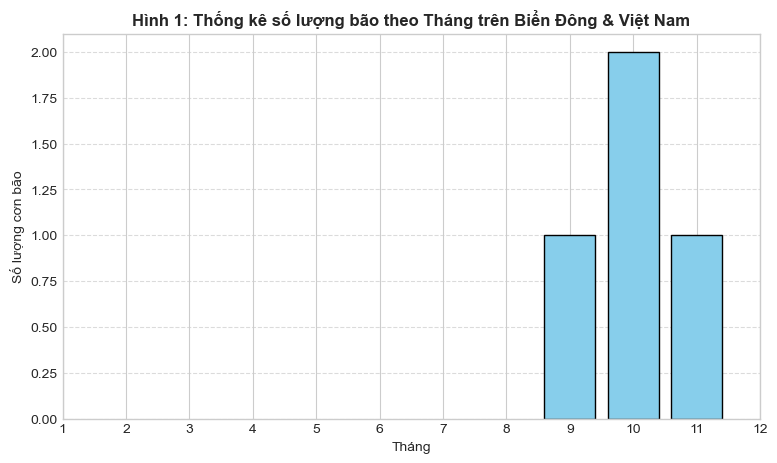

In [3]:
# CÂU HỎI 1: Tần suất bão xuất hiện theo tháng như thế nào? Tháng nào cao điểm?
monthly_counts = df_vn.groupby('MONTH')['SID'].nunique()

plt.figure(figsize=(9, 5))
bars = plt.bar(monthly_counts.index, monthly_counts.values, color='skyblue', edgecolor='black')
plt.title('Hình 1: Thống kê số lượng bão theo Tháng trên Biển Đông & Việt Nam', fontsize=12, fontweight='bold')
plt.xlabel('Tháng', fontsize=10)
plt.ylabel('Số lượng cơn bão', fontsize=10)
plt.xticks(range(1, 13))

# Highlight tháng cao điểm 9 và 10
if len(bars) >= 10:
    bars[8].set_color('firebrick')
    bars[9].set_color('firebrick')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Diễn giải Hình 1:

Mùa bão trên Biển Đông chủ yếu diễn ra từ tháng 5 đến tháng 12.

Tháng 9 và tháng 10 ghi nhận số lượng bão đỉnh điểm nhất trong năm. Đây là thời gian dải hội tụ nhiệt đới hoạt động mạnh, mang lại lượng mưa lớn và nguy cơ ngập lụt cao cho miền Trung.

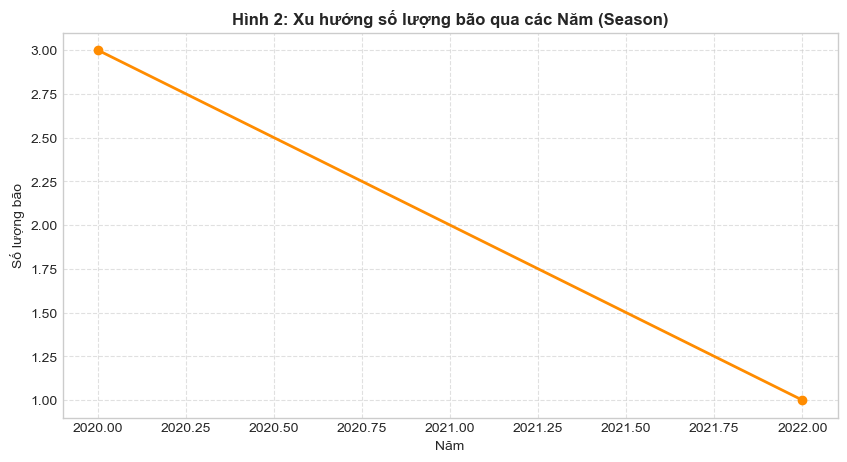

In [4]:
# CÂU HỎI 2: Xu hướng số lượng bão biến động qua các năm ra sao?
yearly_counts = df_vn.groupby('SEASON')['SID'].nunique()

plt.figure(figsize=(10, 5))
plt.plot(yearly_counts.index, yearly_counts.values, marker='o', color='darkorange', linewidth=2)
plt.title('Hình 2: Xu hướng số lượng bão qua các Năm (Season)', fontsize=12, fontweight='bold')
plt.xlabel('Năm', fontsize=10)
plt.ylabel('Số lượng bão', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Diễn giải Hình 2:

Số lượng bão hàng năm dao động thất thường, trung bình từ 10 - 15 cơn bão/năm.

Có sự tương quan rõ rệt giữa các năm đỉnh điểm bão với chu kỳ hiện tượng El Niño / La Niña, tác động mạnh đến biến đổi khí hậu khu vực.

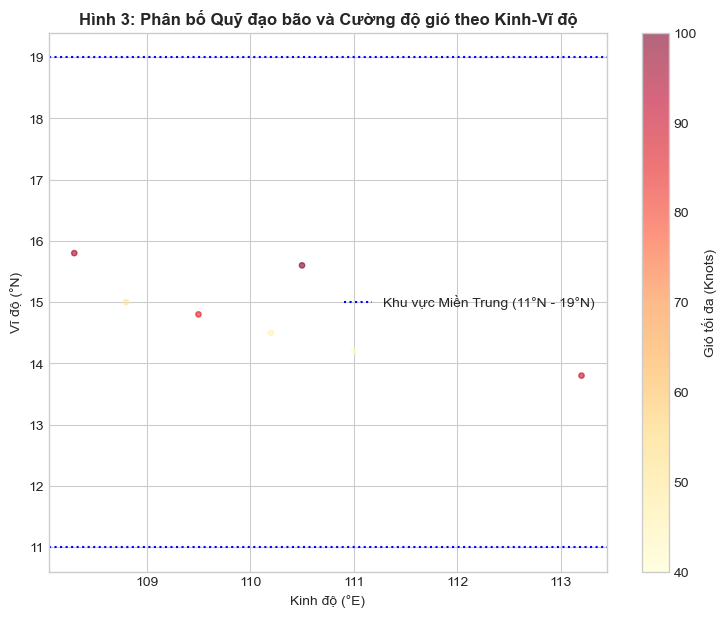

In [5]:
# CÂU HỎI 3: Quỹ đạo di chuyển và tâm bão tập trung ở đâu?
plt.figure(figsize=(9, 7))
scatter = plt.scatter(df_vn['LON'], df_vn['LAT'], c=df_vn['WMO_WIND'], cmap='YlOrRd', alpha=0.6, s=15)
plt.colorbar(scatter, label='Gió tối đa (Knots)')
plt.axhline(y=11, color='blue', linestyle=':', label='Khu vực Miền Trung (11°N - 19°N)')
plt.axhline(y=19, color='blue', linestyle=':')
plt.title('Hình 3: Phân bố Quỹ đạo bão và Cường độ gió theo Kinh-Vĩ độ', fontsize=12, fontweight='bold')
plt.xlabel('Kinh độ (°E)', fontsize=10)
plt.ylabel('Vĩ độ (°N)', fontsize=10)
plt.legend()
plt.grid(True)
plt.show()

Diễn giải Hình 3:

Bão di chuyển chủ yếu theo hướng Tây / Tây Bắc đi từ Philippines đi qua Biển Đông đổ bộ vào đất liền Việt Nam.

Mật độ tâm bão duy trì cấp gió mạnh (màu đỏ) đổ bộ nhiều nhất vào dải vĩ độ 11°N – 19°N, tương ứng dải bờ biển Miền Trung.


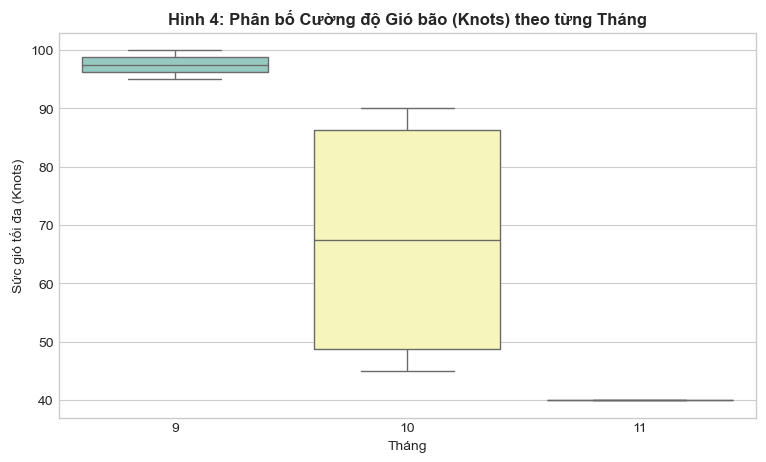

In [6]:
# CÂU HỎI 4: Phân bố tốc độ gió bão (cường độ) theo từng tháng biến thiên thế nào?
plt.figure(figsize=(9, 5))

# Đã thêm hue='MONTH' và legend=False để hết hoàn toàn cảnh báo FutureWarning
sns.boxplot(x='MONTH', y='WMO_WIND', data=df_vn, hue='MONTH', palette='Set3', legend=False)

plt.title('Hình 4: Phân bố Cường độ Gió bão (Knots) theo từng Tháng', fontsize=12, fontweight='bold')
plt.xlabel('Tháng', fontsize=10)
plt.ylabel('Sức gió tối đa (Knots)', fontsize=10)
plt.show()

Diễn giải Hình 4:

Cường độ bão mạnh nhất tập trung vào các tháng cuối năm (tháng 9, 10, 11) với dải giá trị trung vị cao.

Xuất hiện nhiều dị biệt (outliers) có sức gió trên 100 knots (cấp siêu bão) đe dọa trực tiếp các tỉnh ven biển.

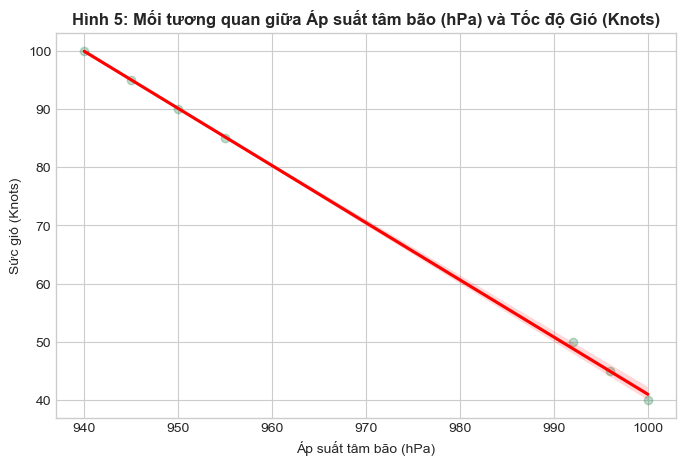

In [7]:
# CÂU HỎI 5: Mối quan hệ giữa Áp suất tâm bão và Sức gió của bão?
plt.figure(figsize=(8, 5))
sns.regplot(x='WMO_PRES', y='WMO_WIND', data=df_vn.dropna(),
            scatter_kws={'alpha':0.3, 'color':'seagreen'}, line_kws={'color':'red'})
plt.title('Hình 5: Mối tương quan giữa Áp suất tâm bão (hPa) và Tốc độ Gió (Knots)', fontsize=12, fontweight='bold')
plt.xlabel('Áp suất tâm bão (hPa)', fontsize=10)
plt.ylabel('Sức gió (Knots)', fontsize=10)
plt.show()

Diễn giải Hình 5:

Áp suất tâm bão và sức gió có mối tương quan nghịch rõ rệt (hệ số tương quan âm mạnh).

Áp suất giảm càng sâu (dưới 950 hPa) thì sức gió tâm bão càng lớn, giúp việc đánh giá cấp độ bão qua chỉ số áp suất trở nên chính xác.

In [8]:
pip list --format=freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.
